This notebook is for Phil to get more acquainted with XGI as he implements an object-oriented model variant with XGI at its base. 

In [39]:
eta = 4/5
gamma = 1
beta = 0.5

In [40]:
import importlib 
m = importlib.import_module(".model", "src")
from matplotlib import pyplot as plt
import numpy as np

In [41]:
H = m.GrowingHypergraph()
H.add_edge((0, 1))

for _ in range(50000):
    H.sample_edge(eta, gamma, beta)

/tmp/ipykernel_155177/3752970361.py:9: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(c.min()/H.H.num_nodes, (c.max()+10000)/H.H.num_nodes)


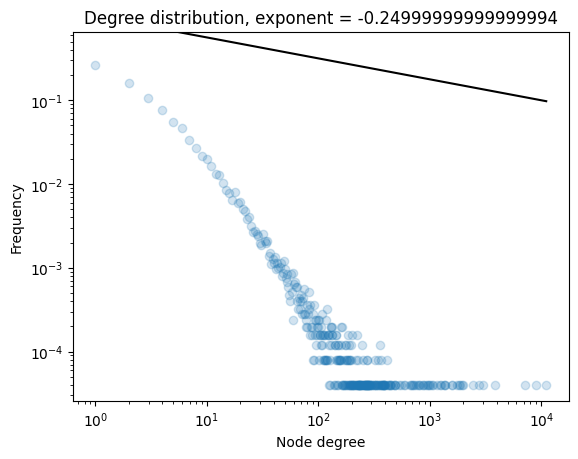

In [50]:
pred_exponent = (eta-1)/eta

degs = H.degree_sequence()
c, b = np.histogram(degs, bins = 100000)
fig, ax = plt.subplots(1, 1)
ax.scatter(b[:-1], c/H.H.num_nodes, alpha = 0.2)

ax.loglog()
ax.set_ylim(c.min()/H.H.num_nodes, (c.max()+10000)/H.H.num_nodes)

x = np.linspace(degs.min(), degs.max())
y = 1*x**pred_exponent



plt.plot(x, y, color = "black")
labs = ax.set(xlabel = "Node degree", ylabel = "Frequency", title = f"Degree distribution, exponent = {pred_exponent}")

The formula 

$$
p_1 = \frac{\beta(\gamma + \beta)}{(\gamma + \beta)^2 + \eta(1-\eta)}
$$

for the expected proportion of degree-1 nodes is derived in the notes, although there is certainly considerable possibility of error. The quick experiment below suggests that this formula is pretty close to right, although it does appear to perhaps be biased a little high after a couple runs. This could be finite-size stuff or it could be a small error in the derivation. 

In [43]:
p_1 = beta*(gamma + beta)/((gamma + beta)**2 + eta*(1-eta))


In [44]:
print(f"proportion of degree-1 nodes = {(degs == 1).mean().round(2)}")
print(f"predicted = {round(p_1, 2)}")

proportion of degree-1 nodes = 0.26
predicted = 0.31
